In [1]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import dill as pickle
from tqdm import tqdm

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.example_libraries import stax

from numpyro.infer import SVI, Trace_ELBO, autoguide
from numpyro import optim
import optax

from fpp.models.np_model import NPModel
from fpp.utils.posterior import multi_corner, dnds_posterior

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.image import imread
mpl.rc_file("matplotlibrc")

# SVI Process: Evolving Posterior

Visualize how the SVI guide/posterior evolves during training by loading
checkpointed params saved by `fit_fermi_svi_process.py`.

In [2]:
# --- Paths ---
svi_process_dir = "../outputs/svi_process"
plots_dir = "../outputs/svi_process/plots"
os.makedirs(plots_dir, exist_ok=True)

# --- Load checkpoint metadata ---
save_steps = np.load(f"{svi_process_dir}/svi_save_steps.npy")
losses = np.load(f"{svi_process_dir}/svi_losses.npy")
print(f"Checkpoint steps: {save_steps}")
print(f"Total training steps: {len(losses)}")

Checkpoint steps: [   0   10   20   30   40   50   60   70   80   90  100  110  120  130
  140  150  160  170  180  190  200  210  220  230  240  250  260  270
  280  290  300  350  400  450  500  550  600  650  700  750  800  850
  900  950 1000 1200 1400 1600 1800 2000 2200 2400 2600 2800 3000 3200
 3400 3600 3800 4000 4200 4400 4600 4800]
Total training steps: 5000


In [4]:
# --- Initialize model + guide (must match fit_fermi_svi_process.py) ---
data = jnp.array(
    np.load("../data/fermi_data_573w/fermi_data_128/fermidata_counts.npy"),
    dtype=jnp.int32,
)

m = NPModel(
    data=data,
    psf_tag='king',
    n_exp=7,
    diffuse_names=["ModelO", "ModelA", "ModelF"],
)

guide = autoguide.AutoIAFNormal(
    m.model,
    num_flows=5,
    hidden_dims=[128, 128],
    nonlinearity=stax.Tanh,
)
m.guide = guide

# Initialize SVI so the guide is properly set up
optimizer = optim.optax_to_numpyro(optax.chain(optax.clip(1.), optax.adam(3e-4)))
loss_fn = Trace_ELBO(num_particles=16, vectorize_particles=True)
svi = SVI(m.model, guide, optimizer, loss_fn)
_ = svi.init(jax.random.PRNGKey(42), data=data)

In [5]:
# --- Sample from guide at each checkpoint ---
num_samples = 50000
rng_key = jax.random.PRNGKey(0)

save_dir = '/n/holystore01/LABS/iaifi_lab/Users/yitians/fermi/fermi-prob-prog/outputs/svi_process'

for step in tqdm(save_steps):
    step = int(step)
    params = pickle.load(open(f"{svi_process_dir}/svi_params_step{step}.p", "rb"))
    raw_samples = guide.sample_posterior(
        rng_key=rng_key,
        params=params,
        sample_shape=(num_samples,),
    )
    pickle.dump(m.expand_samples(raw_samples), open(f"{save_dir}/svi_samples_step{step}.p", "wb"))

100%|██████████| 64/64 [04:37<00:00,  4.34s/it]


## Loss curve

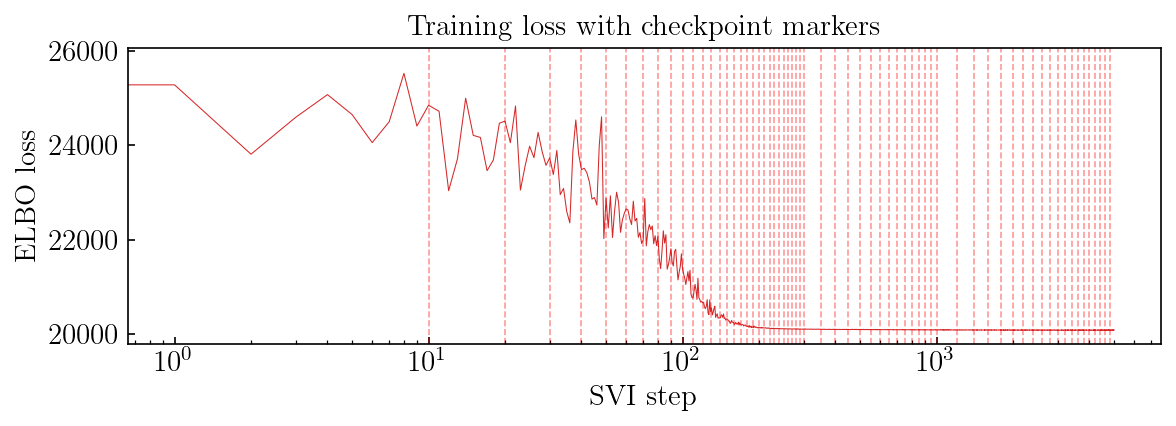

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, lw=0.5)
for step in save_steps:
    if step > 0:
        ax.axvline(step, color='r', ls='--', alpha=0.4, lw=0.8)
ax.set(xlabel='SVI step', ylabel='ELBO loss', title='Training loss with checkpoint markers')
ax.set(xscale='log')
fig.tight_layout()
fig.savefig(f"{plots_dir}/svi_loss_curve.png", dpi=200)

## Evolving corner plots

Overlay posteriors from selected checkpoints to see how the guide sharpens.

In [ ]:
import corner
from PIL import Image

label_latex_d = {
    'S_pib': r'$S_\mathrm{pib}$',
    'S_ics': r'$S_\mathrm{ics}$',
    'S_iso': r'$S_\mathrm{iso}$',
    'S_bub': r'$S_\mathrm{bub}$',
    'S_gce': r'$S_\mathrm{gce}$',
    'S_nfw': r'$S_\mathrm{nfw}$',
    'Sps_dsk': r'$S_\mathrm{dsk}^\mathrm{ps}$',
    'Sps_gce': r'$S_\mathrm{gce}^\mathrm{ps}$',
    'f_bulge_poiss': r'$f_\mathrm{bulge}^\mathrm{pois}$',
    'f_bulge_ps':    r'$f_\mathrm{bulge}^\mathrm{ps}$',
    'gamma_poiss': r'$\gamma^\mathrm{pois}$',
    'gamma_ps':    r'$\gamma^\mathrm{ps}$',
    'C': r'$C$',
    'zs': r'$z_s$',
}

labels = [
    'S_pib', 'S_ics', 'S_gce', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps',
]

range_dict = {
    'S_pib' : [9, 13],
    'S_ics' : [4, 8],
    'S_gce' : [0, 1.5],
    'Sps_gce' : [1, 3],
    'f_bulge_poiss' : [0, 1],
    'f_bulge_ps' : [0, 1],
    'gamma_poiss' : [0.5, 2],
    'gamma_ps' : [0.5, 2]
}

In [52]:
bins_1d_arr = []
range_arr = []
for vn in labels:
    if vn in range_dict:
        vmin, vmax = range_dict[vn]
    bins_1d_arr.append(np.linspace(vmin, vmax, 30+1))
    range_arr.append([vmin, vmax])

Clow = tuple(x / 255 for x in (255, 255, 255))
Cmid = tuple(x / 255 for x in (236, 192, 191))
Chigh = tuple(x / 255 for x in (216, 120, 116))

for idx, step in enumerate(tqdm(save_steps[:])):
    fig = corner.corner(
        pickle.load(open(f"{save_dir}/svi_samples_step{step}.p", "rb")),
        bins_1d_arr=bins_1d_arr,
        range=range_arr,
        var_names=labels,
        fig=None,
        show_titles=False,
        title_fmt=None,
        title_kwargs={"fontsize": 14},
        levels=[0.68, 0.95],
        # color='C0',
        contourf_kwargs={'colors' : [c0_rgb + [0.0], c0_rgb + [0.3], c0_rgb + [0.7]]},
        contour_kwargs={'linewidths': 0},
        plot_contours=True,
        fill_contours=True,
        plot_density=False,
        plot_datapoints=False,
        # hist_kwargs={'density': True},
        hist_kwargs={'histtype': 'stepfilled', 'fc': c0_rgb + [0.2], 'ec': c0_rgb + [0.8], 'lw': 1.5},
        label_kwargs={'fontsize': 30},
        labels=[label_latex_d[k] for k in labels],
        smooth=0.3,
        # smooth1d=0.3,
    )
    fig.text(0.22, 0.95, f'step', ha='right', va='center', fontsize=25)
    fig.text(0.23, 0.95, f'{step}', ha='left', va='center', fontsize=25, color=c0_rgb)
    fig.text(0.22, 0.93, f'loss', ha='right', va='center', fontsize=25)
    fig.text(0.23, 0.93, f'{losses[step]:.1f}', ha='left', va='center', fontsize=25)
    plt.savefig(f'{plots_dir}/svi_process_corner_{step}.png', dpi=200)
    plt.close()

100%|██████████| 64/64 [07:12<00:00,  6.76s/it]


## Evolving dN/dS

In [55]:
labels_func = lambda k: [f'Sps_{k}', f'n1_{k}', f'n2_{k}', f'n3_{k}', f'sb1_{k}', f'lambdas_{k}']

# Select steps for dN/dS evolution
dnds_steps = save_steps

cmap = mpl.colormaps['viridis']
n_show = len(dnds_steps)

for idx, step in enumerate(tqdm(dnds_steps[:])):

    samples = pickle.load(open(f"{save_dir}/svi_samples_step{step}.p", "rb"))

    fig, axs = plt.subplots(2, 1, figsize=(5, 8), sharex=True)

    for ik, k in enumerate(['gce', 'dsk']):
        s, dnds_med, dnds_68, dnds_95 = dnds_posterior(
            samples=samples, theta_keys=labels_func(k), plot=False,
        )
        axs[ik].plot(s, dnds_med, color='k')
        axs[ik].fill_between(s, dnds_68[0], dnds_68[1], alpha=0.5, fc='C0', ec='none')
        axs[ik].fill_between(s, dnds_95[0], dnds_95[1], alpha=0.3, fc='C0', ec='none')

    axs[0].set(xlim=(1, 50), ylim=(1e-7, 1), xscale='log', yscale='log')
    axs[1].set(xlim=(1, 50), ylim=(1e-7, 1), xscale='log', yscale='log')
    axs[0].set(ylabel='$\mathrm{d}N/\mathrm{d}S$ [counts$^{-1}$]')
    axs[1].set(ylabel='$\mathrm{d}N/\mathrm{d}S$ [counts$^{-1}$]')
    axs[1].set(xlabel='$S$ [counts]')
    axs[0].text(0.95, 0.95, 'GCE point source', ha='right', va='top', transform=axs[0].transAxes)
    axs[1].text(0.95, 0.95, 'Disk point source', ha='right', va='top', transform=axs[1].transAxes)

    fig.tight_layout()
    fig.savefig(f'{plots_dir}/dnds_step{step}.png', dpi=200)
    plt.close()

100%|██████████| 64/64 [01:44<00:00,  1.63s/it]


# Combine and make GIF

In [65]:
def combine_plots(step):
    fn1 = f'{plots_dir}/corner/svi_process_corner_{step}.png'
    fn2 = f'{plots_dir}/dnds/dnds_step{step}.png'

    img1 = imread(fn1)
    img2 = imread(fn2)

    # Get aspect ratios from actual pixel dimensions
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    asp1 = w1 / h1
    asp2 = w2 / h2

    scale2 = 0.7  # shrink the right plot to 70% height

    # Left plot fills full height; right plot is 70% height, centered
    # Normalize so left plot has height 1
    left_w = asp1       # width of left plot (height=1)
    right_h = scale2
    right_w = asp2 * right_h

    total_w = left_w + right_w
    fig_height = 6
    fig_width = fig_height * total_w

    fig = plt.figure(figsize=(fig_width, fig_height))

    # Axes positions in figure coords [left, bottom, width, height]
    ax1 = fig.add_axes([0, 0, left_w / total_w, 1.0])
    ax2 = fig.add_axes([left_w / total_w, (1 - scale2) / 2, right_w / total_w, scale2])

    ax1.imshow(img1)
    ax1.axis('off')
    ax2.imshow(img2)
    ax2.axis('off')

    plt.savefig(f'{plots_dir}/combined/{step}.png', bbox_inches='tight', dpi=300)
    plt.close()

In [67]:
for step in tqdm(save_steps[:]):
    combine_plots(step)

  0%|          | 0/64 [00:00<?, ?it/s]

100%|██████████| 64/64 [02:53<00:00,  2.72s/it]


# Post-processing

In [3]:
img = imread('../outputs/svi_process/plots/combined/0.png')
dpi = 200
height, width = img.shape[:2]

def draw_line(ax, points, color='k', lw=2, **line_kwargs):
    xs = [x * width for x, y in points]
    ys = [y * height for x, y in points]
    ax.plot(xs, ys, color=color, lw=lw, **line_kwargs)

def draw_arrow(ax, start, end, color='k', lw=2, **arrow_kwargs):
    x0, y0 = start[0] * width, start[1] * height
    x1, y1 = end[0] * width, end[1] * height
    arrow_kwargs.setdefault('arrowstyle', '->')
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0), color=color, lw=lw, arrowprops=arrow_kwargs)

def draw_text(ax, pos, text, fontsize=16, color='k', **text_kwargs):
    x = pos[0] * width
    y = pos[1] * height
    text_kwargs.setdefault('ha', 'left')
    text_kwargs.setdefault('va', 'center')
    ax.text(x, y, text, fontsize=fontsize, color=color, **text_kwargs)

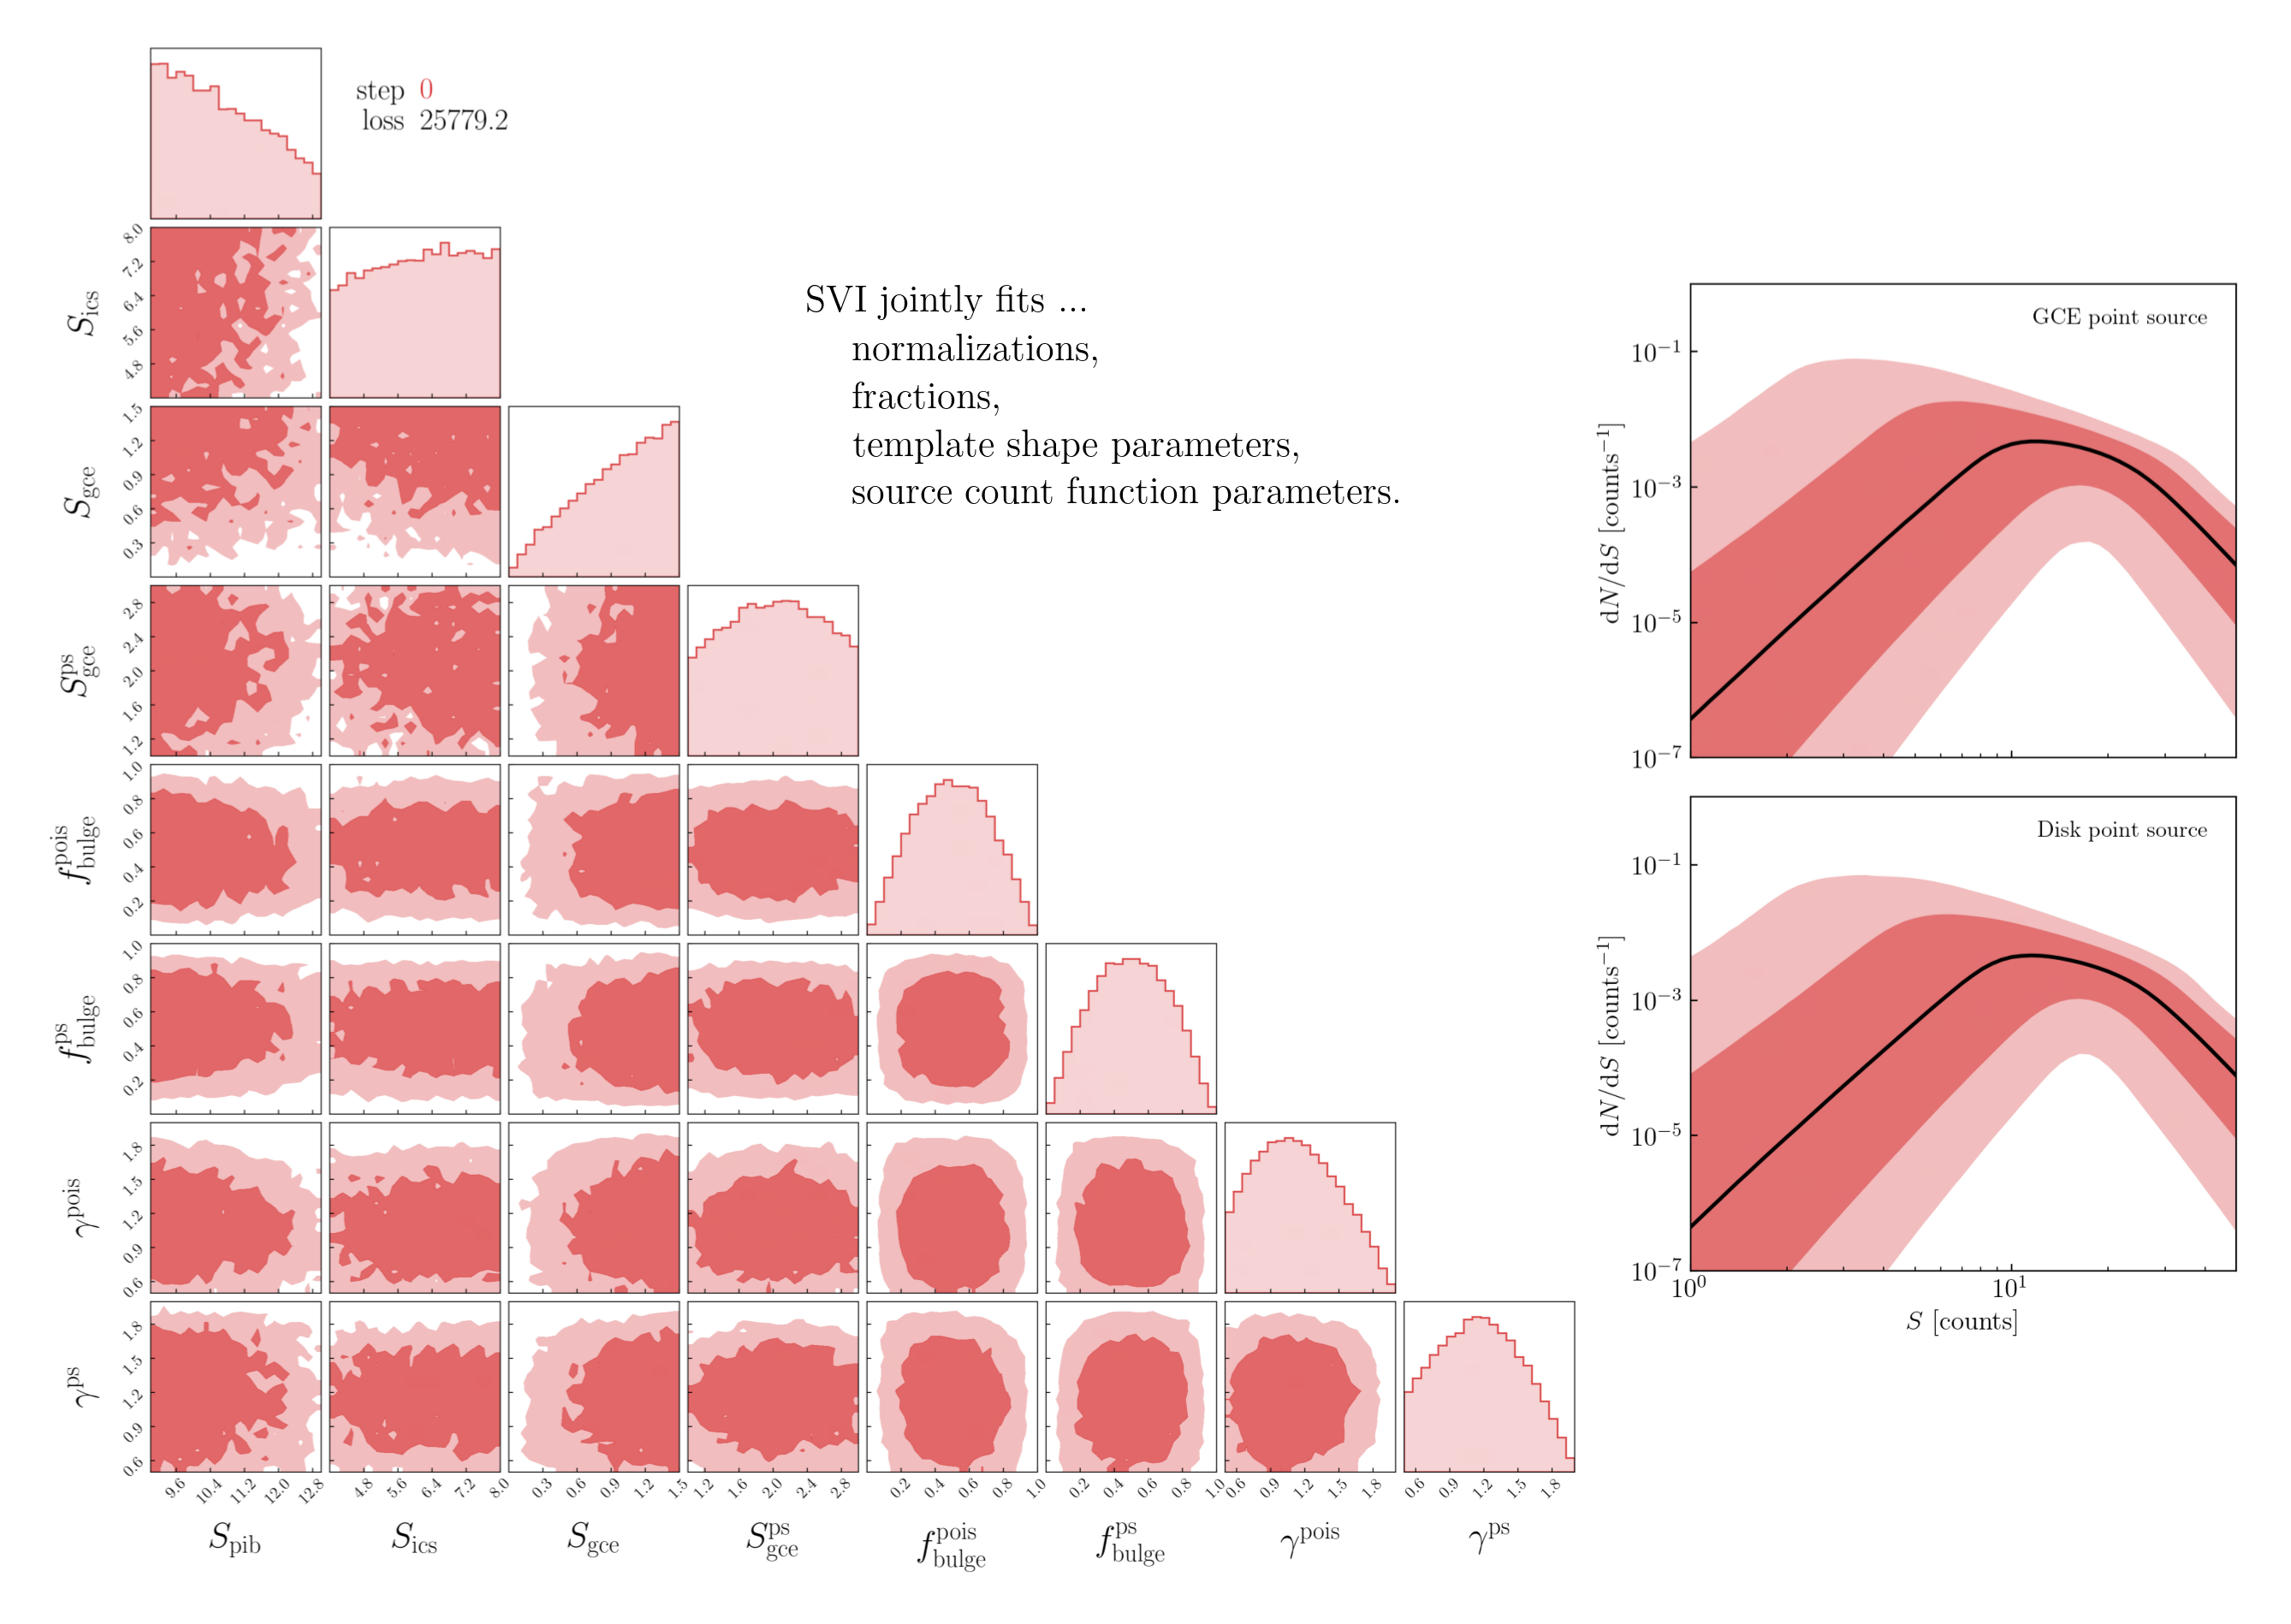

In [ ]:
fig = plt.figure(figsize=(width / dpi, height / dpi), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])

ax.imshow(img)
ax.axis('off')
ax.set_xlim(0, width)
ax.set_ylim(height, 0)

draw_text(ax, (0.35, 0.18), 'SVI jointly fits ...')
draw_text(ax, (0.37, 0.21), 'normalizations,')
draw_text(ax, (0.37, 0.24), 'fractions,')
draw_text(ax, (0.37, 0.27), 'template shape parameters,')
draw_text(ax, (0.37, 0.30), 'source count function parameters.')

fig.savefig('test.png', dpi=dpi, pad_inches=0)
# plt.close(fig)

In [ ]:
for i in tqdm(save_steps):
    img = imread(f'../outputs/svi_process/plots/combined/{i}.png')

    fig = plt.figure(figsize=(width / dpi, height / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])

    ax.imshow(img)
    ax.axis('off')
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)

    draw_text(ax, (0.35, 0.18), 'SVI jointly fits ...')
    draw_text(ax, (0.37, 0.21), 'normalizations,')
    draw_text(ax, (0.37, 0.24), 'fractions,')
    draw_text(ax, (0.37, 0.27), 'template shape parameters,')
    draw_text(ax, (0.37, 0.30), 'source count function parameters.')

    fig.savefig(f'../outputs/svi_process/plots/postprocessed/{i}.png', dpi=dpi, pad_inches=0)

  0%|          | 0/64 [00:00<?, ?it/s]

 31%|███▏      | 20/64 [00:27<00:53,  1.21s/it]/tmp/ipykernel_2391794/3171636129.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(width / dpi, height / dpi), dpi=dpi)
100%|██████████| 64/64 [01:22<00:00,  1.29s/it]


# GIF

In [5]:
from PIL import Image

def make_gif(files, output, dt=100, dt_final=1000, loop=0):
    frames = [Image.open(f).convert("RGBA") for f in files]
    durations = [dt] * (len(frames) - 1) + [dt_final]
    frames[0].save(output, save_all=True, append_images=frames[1:], duration=durations, loop=loop)

In [8]:
make_gif(
    [f'{plots_dir}/postprocessed/{step}.png' for step in save_steps],
    f'{plots_dir}/svi.gif',
    dt=100,
    dt_final=1500,
    loop=0,
)